STEP 1: UAV <-> SRTM bias correction on stable terrain

[1/5] Loading DEMs and shapefiles...
  UAV grid resolution: 0.39 m,  shape: (9673, 10374)

[2/5] Rasterizing stable-terrain and glacier masks onto UAV grid...
  Stable-terrain pixels: 3,721,688
  Glacier pixels       : 16,765,731

[3/5] Computing terrain slope/aspect from UAV (reference)...

[4/5] Correcting SRTM onto UAV (stable terrain only, method='auto')...
  RAW SRTM-UAV bias (stable terrain)
    mean=+30.933 m  median=+30.484 m  NMAD=7.867 m  std=15.014 m  n=3,721,688

  --- Trying Nuth-Kaab (3-D co-registration) ---


d:\thesis\Malangutti\Code\dem_utils.py:387: RuntimeWarning: Mean of empty slice
  return np.nanmean(reshaped, axis=(1, 3))


  Fitting on a coarsened grid: 0.39 m -> 30.1 m (factor 78) to avoid fine-texture noise
  iter    dE(m)    dN(m)    dZ(m)   |shift|     NMAD
     1   -0.822   -0.814  +99.981    1.1567    6.305
     2   +0.957   +0.649  -227.356    1.1567    6.264
     3   -0.818   -0.818  +312.948    1.1567    6.295  (bias near bound)
     4   +0.900   +0.727  -312.948    1.1567    6.272  (bias near bound)
     5   -0.819   -0.817  +312.948    1.1567    6.283  (bias near bound)
     6   +0.899   +0.727  -312.948    1.1567    6.268  (bias near bound)
     7   -0.819   -0.817  +312.948    1.1567    6.285  (bias near bound)
     8   +0.895   +0.733  -312.948    1.1567    6.341  (bias near bound)
     9   -0.819   -0.817  +312.948    1.1567    6.240  (bias near bound)
    10   +0.895   +0.733  -312.948    1.1567    6.336  (bias near bound)
    11   -0.819   -0.817  +312.948    1.1567    6.225  (bias near bound)
    12   +0.899   +0.728  -312.948    1.1567    6.354  (bias near bound)
    13   -0.819   -0.8

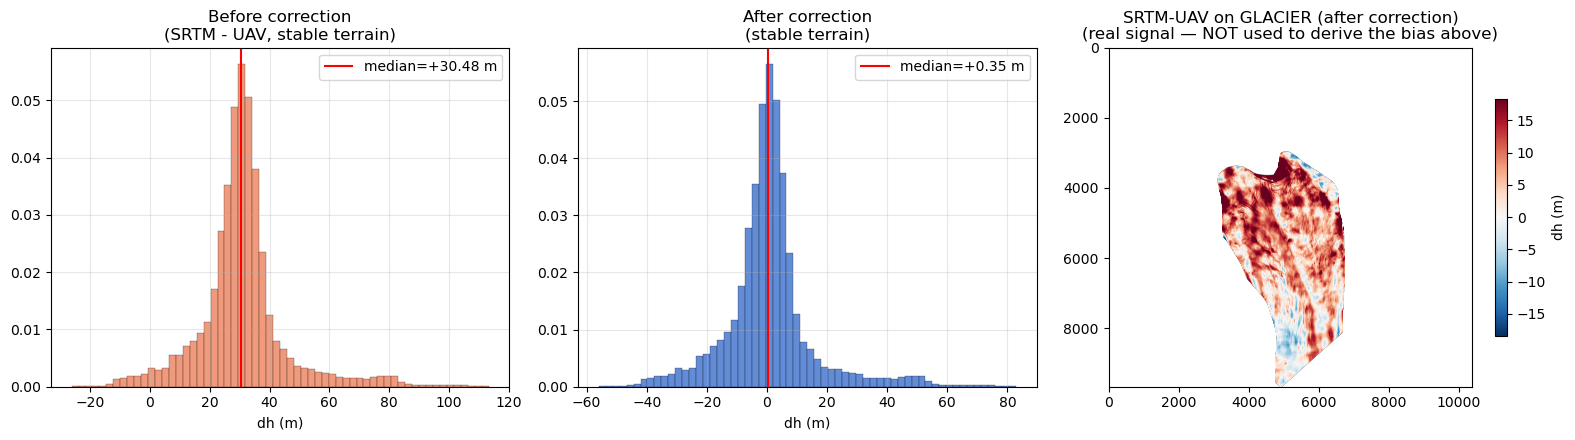


Summary:
  Correction applied (nuth_kaab): {'dE': np.float64(0.45039579421731424), 'dN': np.float64(-0.5139951713814794), 'dZ': np.float64(30.072021484375), 'n_iter': 15, 'converged': False, 'fit_grid_res_m': 30.073913999999913}
  Output: D:\thesis\Malangutti/Step1_UAV_SRTM\SRTM_corrected_by_UAV_full_extent.tif

NOTE: this corrected DEM is your input REF for Step 2.


In [1]:
"""
STEP 2 — SRTM (from Step 1) <-> TanDEM-X co-registration (stable terrain)
==========================================================================
Goal: use TanDEM-X (a globally-consistent, high-accuracy DEM) as a second
independent reference to further tie down SRTM's absolute vertical/
horizontal position, again using stable terrain only.

Output of this step (`SRTM_final_corrected.tif`) is the DEM you should
treat as your "epoch ~2000" reference surface for Step 3 (ASTER
differencing). Keep this file's date fixed at the SRTM acquisition date
(e.g. Feb 2000), NOT the TanDEM-X date — TanDEM-X is only used here to
correct the geometric/vertical bias of SRTM, not to replace SRTM's
elevation values.

IMPORTANT: exactly as in Step 1, the bias/co-registration parameters
are computed on STABLE terrain only. Never fit this using the glacier
(SRTM and TanDEM-X are ~11-15 years apart -> glacier dh there is real
signal, not error).
"""

import os
import numpy as np
import matplotlib.pyplot as plt

from dem_utils import (
    load_dem, reproject_match, rasterize_mask, compute_slope_aspect,
    vertical_bias_correction, nuth_kaab_coregister, print_stats, nmad,
    save_raster, apply_planar_shift,
)

# ============================== CONFIG ======================================
UAV_PATH     = r"D:\thesis\Malangutti\Malanggutti.tif"
SRTM_PATH    = r"D:\thesis\Malangutti\Test\Malangutii_SRTM.tif"
STABLE_SHP   = r"D:\thesis\Malangutti\Stable Terrain\Stable_terrain.shp"
GLACIER_SHP  = r"D:\thesis\Malangutti\Glacier_RGI_7\Malangutti_Glacier.shp"

OUT_DIR      = r"D:\thesis\Malangutti/Step1_UAV_SRTM"

METHOD       = "auto"          # "auto" (recommended), "nuth_kaab", or "vertical"
SRC          = "srtm"          # DEM being corrected
REF          = "uav"           # DEM used as the accurate reference
MAX_DH_COREG = 200.0           # discard obviously-wrong pairs before fitting (m)
MIN_SLOPE    = 3.0             # degrees; NK needs sloped terrain to work
COREG_FIT_RES_M = 30.0         # fit Nuth-Kaab on a grid coarsened to ~this
                                # resolution (set to your coarser DEM's native
                                # resolution) — avoids fine UAV texture
                                # destabilizing the fit; the final shift is
                                # still applied at full UAV resolution.
# =============================================================================

os.makedirs(OUT_DIR, exist_ok=True)

print("=" * 70)
print("STEP 1: UAV <-> SRTM bias correction on stable terrain")
print("=" * 70)

print("\n[1/5] Loading DEMs and shapefiles...")
uav = load_dem(UAV_PATH)
srtm_raw = load_dem(SRTM_PATH)

# UAV is almost always the finer grid; use it as the working grid.
srtm = reproject_match(srtm_raw, uav)

res_x, _ = uav.rio.resolution()
RES_M = abs(res_x)
print(f"  UAV grid resolution: {RES_M:.2f} m,  shape: {uav.shape}")

print("\n[2/5] Rasterizing stable-terrain and glacier masks onto UAV grid...")
stable_mask = rasterize_mask(STABLE_SHP, uav)
glacier_mask = rasterize_mask(GLACIER_SHP, uav)
print(f"  Stable-terrain pixels: {stable_mask.sum():,}")
print(f"  Glacier pixels       : {glacier_mask.sum():,}")

uav_arr = uav.values.astype(float)
srtm_arr = srtm.values.astype(float)

src_arr, ref_arr = (srtm_arr, uav_arr) if SRC == "srtm" else (uav_arr, srtm_arr)
ref_label = REF.upper()
src_label = SRC.upper()

print(f"\n[3/5] Computing terrain slope/aspect from {ref_label} (reference)...")
slope, aspect = compute_slope_aspect(ref_arr, RES_M)

print(f"\n[4/5] Correcting {src_label} onto {ref_label} "
      f"(stable terrain only, method='{METHOD}')...")

dh_raw = (src_arr - ref_arr)
m_raw = stable_mask & np.isfinite(dh_raw) & (np.abs(dh_raw) < MAX_DH_COREG)
print_stats(dh_raw[m_raw], f"RAW {src_label}-{ref_label} bias (stable terrain)")

candidates = {}

if METHOD in ("auto", "nuth_kaab"):
    print("\n  --- Trying Nuth-Kaab (3-D co-registration) ---")
    try:
        nk_arr, nk_shift, nk_diag = nuth_kaab_coregister(
            src_arr, ref_arr, slope, aspect, RES_M, stable_mask,
            max_dh=MAX_DH_COREG, min_slope_deg=MIN_SLOPE,
            coreg_grid_res_m=COREG_FIT_RES_M,
        )
        candidates["nuth_kaab"] = (nk_arr, nk_shift, nk_diag["nmad_post"])
    except Exception as e:
        print(f"  Nuth-Kaab failed: {e}")

if METHOD in ("auto", "vertical"):
    print("\n  --- Trying simple vertical median shift ---")
    v_arr, v_bias, v_m = vertical_bias_correction(
        src_arr, ref_arr, stable_mask, max_dh=MAX_DH_COREG,
    )
    v_dh_post = (v_arr - ref_arr)
    v_m_post = stable_mask & np.isfinite(v_dh_post) & (np.abs(v_dh_post) < MAX_DH_COREG)
    v_nmad_post = nmad(v_dh_post[v_m_post])
    print(f"  Vertical-only NMAD (stable terrain): {v_nmad_post:.3f} m")
    candidates["vertical"] = (v_arr, {"dZ": v_bias}, v_nmad_post)

if not candidates:
    raise RuntimeError("No correction method succeeded — check inputs.")

if METHOD == "auto":
    chosen = min(candidates, key=lambda k: candidates[k][2])
    print(f"\n  AUTO: selected '{chosen}' "
          f"(NMAD {candidates[chosen][2]:.3f} m vs "
          + ", ".join(f"{k}={v[2]:.3f} m" for k, v in candidates.items() if k != chosen)
          + ")")
else:
    chosen = METHOD

corrected_arr, bias_report, _ = candidates[chosen]

dh_post = (corrected_arr - ref_arr)
m_post = stable_mask & np.isfinite(dh_post) & (np.abs(dh_post) < MAX_DH_COREG)
print_stats(dh_post[m_post], f"AFTER correction (stable terrain, method='{chosen}')")

if SRC == "srtm":
    srtm_corrected_arr = corrected_arr
else:
    # We corrected UAV instead; SRTM stays as-is for downstream use.
    srtm_corrected_arr = srtm_arr

print("\n[5/5] Saving corrected DEM (full extent) and diagnostic plots...")

# IMPORTANT: `corrected_arr` above lives on the UAV's small grid/extent
# (needed for the fine-resolution bias fit), but Step 2/3 need a corrected
# SRTM that covers the FULL original SRTM tile, not just the drone
# footprint. Apply the same shift to the ORIGINAL, full-extent SRTM here
# instead of saving the small UAV-clipped version.
dE = bias_report.get("dE", 0.0)
dN = bias_report.get("dN", 0.0)
dZ = bias_report.get("dZ", 0.0)

if SRC == "srtm":
    srtm_full_corrected = apply_planar_shift(srtm_raw, dE, dN, dZ)
    out_name = f"{src_label}_corrected_by_{ref_label}_full_extent.tif"
    out_path = os.path.join(OUT_DIR, out_name)
    srtm_full_corrected.rio.to_raster(out_path, compress="LZW")
    print(f"  Saved FULL-EXTENT corrected SRTM (shape {srtm_full_corrected.shape}, "
          f"same extent as original SRTM tile): {out_path}")
else:
    # Corrected UAV itself -- UAV's own small extent IS the meaningful
    # extent here, so saving on its own grid is correct in this branch.
    out_name = f"{src_label}_corrected_by_{ref_label}.tif"
    out_path = os.path.join(OUT_DIR, out_name)
    save_raster(corrected_arr, uav, uav.rio.crs, out_path)

# Small UAV-grid version, kept ONLY for the diagnostic plots below (glacier
# panel needs to be on the fine UAV grid to show useful spatial detail over
# the drone footprint) -- this file is NOT what Step 2 should read.
diag_name = f"{src_label}_corrected_by_{ref_label}_UAVgrid_DIAGNOSTIC_ONLY.tif"
save_raster(corrected_arr, uav, uav.rio.crs, os.path.join(OUT_DIR, diag_name))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(dh_raw[m_raw], bins=60, color="#ee8866", alpha=0.85,
             edgecolor="k", lw=0.2, density=True)
axes[0].axvline(np.median(dh_raw[m_raw]), color="red", lw=1.5,
                 label=f"median={np.median(dh_raw[m_raw]):+.2f} m")
axes[0].set_title(f"Before correction\n({src_label} - {ref_label}, stable terrain)")
axes[0].set_xlabel("dh (m)"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(dh_post[m_post], bins=60, color="#4878d0", alpha=0.85,
             edgecolor="k", lw=0.2, density=True)
axes[1].axvline(np.median(dh_post[m_post]), color="red", lw=1.5,
                 label=f"median={np.median(dh_post[m_post]):+.2f} m")
axes[1].set_title("After correction\n(stable terrain)")
axes[1].set_xlabel("dh (m)"); axes[1].legend(); axes[1].grid(alpha=0.3)

vmax = min(20, np.nanpercentile(np.abs(dh_post[glacier_mask & np.isfinite(dh_post)]), 95)
           if np.any(glacier_mask & np.isfinite(dh_post)) else 20)
dh_gl_plot = np.where(glacier_mask, dh_post, np.nan)
im = axes[2].imshow(dh_gl_plot, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[2].set_title(f"{src_label}-{ref_label} on GLACIER (after correction)\n"
                   f"(real signal — NOT used to derive the bias above)")
plt.colorbar(im, ax=axes[2], shrink=0.7, label="dh (m)")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "step1_diagnostics.png"), dpi=150)
plt.show()

print("\nSummary:")
print(f"  Correction applied ({chosen}): {bias_report}")
print(f"  Output: {os.path.join(OUT_DIR, out_name)}")
print("\nNOTE: this corrected DEM is your input REF for Step 2.")
